# Box plots

A box plot compresses a whole distribution into five numbers:

| | |
|---|---|
| **minimum** | the smallest value |
| **lower quartile** (Q1) | a quarter of the data lies below it |
| **median** (Q2) | half the data lies below it |
| **upper quartile** (Q3) | three quarters of the data lie below it |
| **maximum** | the largest value |

The box spans Q1 to Q3 — the **interquartile range**, the middle half of the data — with the median
drawn inside it. The whiskers reach out to the extremes.

That is the definition. Matplotlib does not draw it by default, and the difference is the first thing
this notebook covers, because a figure that says "whisker" while meaning something else is a figure
that misleads a reader who knows the definition above.

All data here is synthetic and all axis labels are deliberately generic — this notebook is about how a
figure is built and styled, not about any particular measurement.

In [1]:
%matplotlib inline

# Jupyter crops every inline preview with bbox_inches="tight". That defeats the exact column widths
# this package exists to guarantee, and because the themes sit the axes close to the canvas edge, the
# crop slices through the top and right spines. Turn it off so previews match the files jf.save() writes.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

# jf.save() reports what it wrote through the "journalfig" logger instead of printing. Raise that one
# logger -- a blanket logging.basicConfig(level="INFO") also switches on fontTools, which logs a dozen
# subsetting lines per PDF.
import logging

logging.basicConfig(format="%(message)s")
logging.getLogger("journalfig").setLevel(logging.INFO)

import numpy as np
import matplotlib.pyplot as plt

import journalfig as jf

# The themes render previews at 600 dpi, which makes every embedded image in a notebook large. This
# only touches the on-screen preview; jf.save() exports at savefig.dpi regardless.
PREVIEW_DPI = 150


def preview(journal, **kwargs):
    """Apply a theme, then drop the on-screen DPI so this notebook stays light."""
    jf.use(journal, **kwargs)
    plt.rcParams["figure.dpi"] = PREVIEW_DPI


rng = np.random.default_rng(0)
print("journalfig", jf.__version__, "| themes:", jf.JOURNALS)

journalfig 0.1.0 | themes: ('nature', 'aps', 'elsevier')


## Five groups, five different shapes

Box plots earn their place when several distributions have to be compared in one panel, so the data
here is five groups of different size and different shape — symmetric, wide, skewed, tight, and
heavy-tailed. Sample sizes differ deliberately: a box plot hides `n` completely, which is a habit
worth seeing before it becomes a problem.

In [2]:
rng = np.random.default_rng(7)

groups = {
    "Group A": rng.normal(4.0, 1.0, 120),            # symmetric
    "Group B": rng.normal(4.6, 1.6, 90),             # symmetric, wider
    "Group C": rng.lognormal(1.2, 0.45, 140),        # skewed
    "Group D": rng.normal(3.4, 0.7, 60),             # tight
    "Group E": rng.standard_t(3, 200) * 0.9 + 4.2,   # heavy-tailed
}

# np.percentile with the default method is exactly what matplotlib uses to place the box, so these
# numbers and the drawn figure cannot disagree.
print(f"{'group':8s} {'n':>4s} {'min':>7s} {'Q1':>7s} {'median':>7s} {'Q3':>7s} {'max':>7s} {'IQR':>7s}")
for name, sample in groups.items():
    lo, q1, med, q3, hi = np.percentile(sample, [0, 25, 50, 75, 100])
    print(f"{name:8s} {sample.size:4d} {lo:7.2f} {q1:7.2f} {med:7.2f} {q3:7.2f} {hi:7.2f} {q3 - q1:7.2f}")

group       n     min      Q1  median      Q3     max     IQR
Group A   120    1.48    3.35    3.90    4.35    6.24    1.00
Group B    90    1.19    3.50    4.37    5.80    7.61    2.30
Group C   140    0.77    2.44    3.26    4.17    8.26    1.73
Group D    60    2.04    2.85    3.35    3.73    4.98    0.88
Group E   200   -1.06    3.54    4.16    4.80    8.79    1.26


## The default whisker is not the minimum and maximum

By default matplotlib follows **Tukey's convention**: each whisker stops at the most extreme point
still within 1.5 × IQR of the box, and every point beyond that is drawn individually as a *flier*.
The whisker end is a data point, but it is not the minimum.

Pass `whis=(0, 100)` — the percentiles the whiskers should reach — to get the literal five-number
summary instead. Then there are no fliers by construction, because nothing is left outside.

Neither convention is wrong. Tukey's separates the bulk of the distribution from its tail, which is
usually what a reader wants; the five-number summary is the one that matches the definition of a box
plot. What is wrong is not knowing which one the figure shows, so **say it in the caption**.

Text(0, 0.5, 'Value (a.u.)')

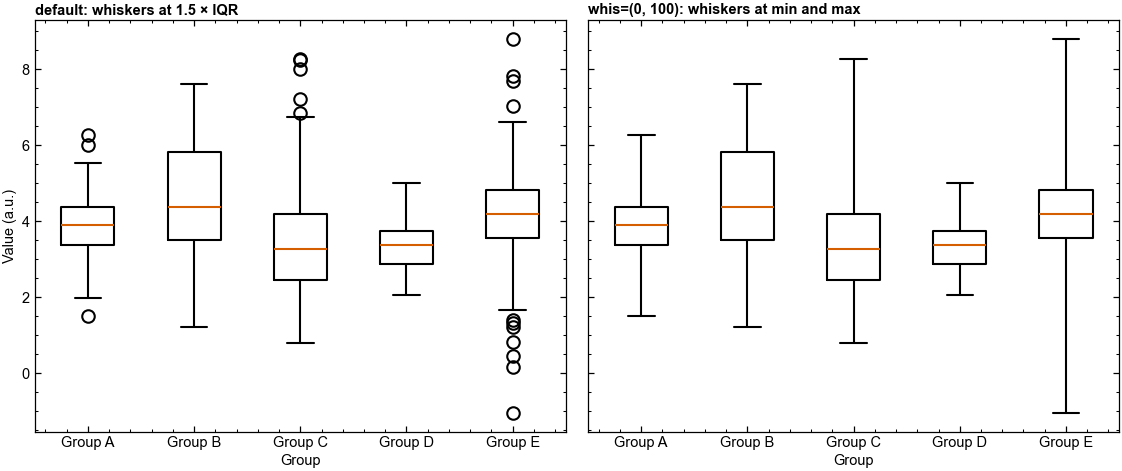

In [3]:
preview("elsevier")

fig, axs = jf.subplots("elsevier", 1, 2, width="double", ratio=0.42, sharey=True)

axs[0].boxplot(list(groups.values()))
axs[0].set_title("default: whiskers at 1.5 × IQR")

axs[1].boxplot(list(groups.values()), whis=(0, 100))
axs[1].set_title("whis=(0, 100): whiskers at min and max")

for ax in axs:
    ax.set_xticks(range(1, len(groups) + 1), list(groups))
    ax.set_xlabel("Group")
axs[0].set_ylabel("Value (a.u.)")

The panels differ, and by how much is worth reading off rather than eyeballing. `boxplot_stats()` is
the function `boxplot()` itself calls, so it reports exactly what was drawn.

In [4]:
from matplotlib.cbook import boxplot_stats

print(f"{'group':8s} {'true min':>9s} {'whisker':>8s}   {'true max':>9s} {'whisker':>8s}   {'fliers':>6s}")
for name, sample in groups.items():
    stats = boxplot_stats(sample)[0]          # the defaults: whis=1.5
    print(f"{name:8s} {sample.min():9.2f} {stats['whislo']:8.2f}   "
          f"{sample.max():9.2f} {stats['whishi']:8.2f}   {len(stats['fliers']):6d}")

print()
print("Groups B and D have no points beyond 1.5 × IQR, so for them the two conventions coincide.")

group     true min  whisker    true max  whisker   fliers
Group A       1.48     1.96        6.24     5.52        3
Group B       1.19     1.19        7.61     7.61        0
Group C       0.77     0.77        8.26     6.73        5
Group D       2.04     2.04        4.98     4.98        0
Group E      -1.06     1.66        8.79     6.60       11

Groups B and D have no points beyond 1.5 × IQR, so for them the two conventions coincide.


## Anatomy of one box

The same five numbers, labelled on the figure. Worth building once: the annotation coordinates come
from `boxplot_stats()`, so the labels track the data instead of being positioned by hand and going
stale the moment the numbers change.

violations: []


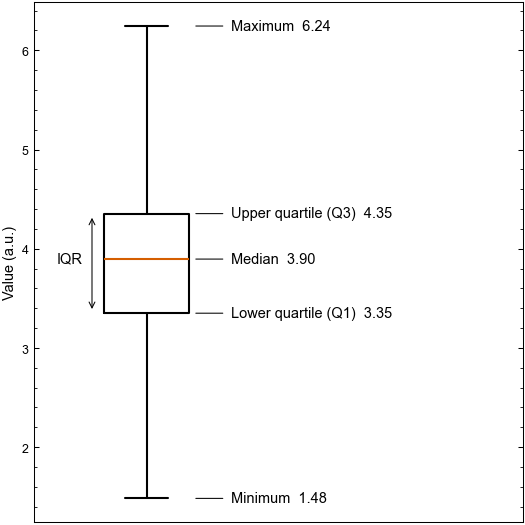

In [5]:
preview("nature")

sample = groups["Group A"]
stats = boxplot_stats(sample, whis=(0, 100))[0]

fig, ax = jf.subplots("nature", width="single", ratio=1.0)
ax.boxplot(sample, whis=(0, 100), widths=0.45)

annotations = [
    ("Maximum", stats["whishi"]),
    ("Upper quartile (Q3)", stats["q3"]),
    ("Median", stats["med"]),
    ("Lower quartile (Q1)", stats["q1"]),
    ("Minimum", stats["whislo"]),
]
for label, value in annotations:
    ax.annotate(f"{label}  {value:.2f}", xy=(1.24, value), xytext=(1.45, value),
                va="center", arrowprops={"arrowstyle": "-", "linewidth": 0.5,
                                         "color": jf.COLORS["black"]})

ax.annotate("", xy=(0.71, stats["q1"]), xytext=(0.71, stats["q3"]),
            arrowprops={"arrowstyle": "<->", "linewidth": 0.5, "color": jf.COLORS["black"]})
ax.annotate("IQR", xy=(0.66, stats["med"]), ha="right", va="center")

ax.set_xlim(0.4, 3.0)
ax.set_xticks([])
ax.set_ylabel("Value (a.u.)")
print("violations:", jf.check(fig, warn=False))

## Tick labels: name the groups, not the positions

Boxes are placed at 1, 2, 3, … and those integers are meaningless to a reader. Two ways to replace
them, and the choice is about which matplotlib you support:

- `ax.set_xticks(positions, names)` — works on every version this package supports.
- `boxplot(..., tick_labels=names)` — reads better, but the keyword was called `labels` before
  matplotlib 3.9 and passing the old name now raises a deprecation warning.

The notebooks here use `set_xticks`, which sidesteps the rename entirely.

Text(0, 0.5, 'Value (a.u.)')

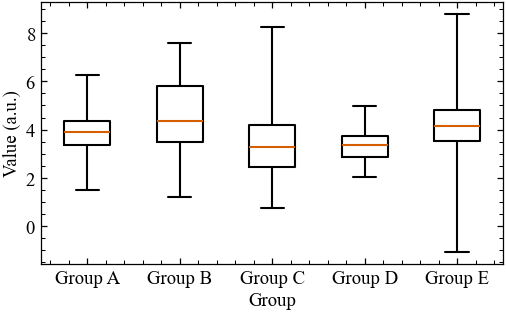

In [6]:
preview("aps")

fig, ax = jf.subplots("aps", width="single")
ax.boxplot(list(groups.values()), whis=(0, 100))
ax.set_xticks(range(1, len(groups) + 1), list(groups))
ax.set_xlabel("Group")
ax.set_ylabel("Value (a.u.)")

## The property cycle does not reach a box plot

Every box comes out black whatever the theme's colour cycle says — the same trap as `histtype="step"`
in [`03_histograms.ipynb`](03_histograms.ipynb), and for the same reason: these artists are built
before the cycle is consulted.

To colour them, `patch_artist=True` turns each box from a `Line2D` outline into a fillable `Patch`,
which you then colour yourself. Two details make the result readable rather than merely coloured:

- **Set the median colour explicitly.** A black median line on a dark box disappears; the median is
  the single most important mark in the plot.
- **Keep the fill pale.** `alpha`, or a light face colour, so the median and the whiskers still read
  as the foreground.

box artists are now: PathPatch
diamond = mean, line = median; they separate when the distribution is skewed


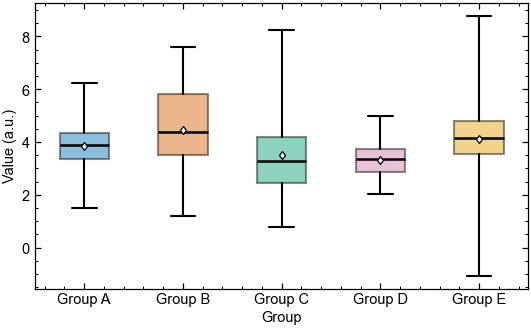

In [7]:
preview("elsevier")

fig, ax = jf.subplots("elsevier", width="single")
artists = ax.boxplot(list(groups.values()), whis=(0, 100), patch_artist=True,
                     medianprops={"color": jf.COLORS["black"], "linewidth": 1.2},
                     showmeans=True, meanprops={"marker": "d", "markersize": 3,
                                                "markerfacecolor": "white",
                                                "markeredgecolor": jf.COLORS["black"]})

for box, colour in zip(artists["boxes"], jf.COLOR_CYCLE):
    box.set_facecolor(colour)
    box.set_alpha(0.45)
    box.set_edgecolor(jf.COLORS["black"])

ax.set_xticks(range(1, len(groups) + 1), list(groups))
ax.set_xlabel("Group")
ax.set_ylabel("Value (a.u.)")
print("box artists are now:", type(artists["boxes"][0]).__name__)
print("diamond = mean, line = median; they separate when the distribution is skewed")

`showmeans=True` is a cheap addition with real information in it: the mean and the median coincide
for a symmetric distribution and pull apart for a skewed one, so the gap between the diamond and the
line in Group C *is* the skew.

## Fliers at print size

Matplotlib's default flier is an open circle at the theme's marker size. Group E has eleven of them
and at 89 mm wide they stack into a smear that draws more attention than the box.

Shrinking them is the obvious fix and it has a floor: APS requires symbols at least 1.0 mm across.
`jf.check()` knows the number, so the trade-off is measured rather than guessed.

markersize 2 pt is 0.71 mm across
  [marker] marker diameter is 0.71 mm, below the 1.0 mm minimum
  [marker] marker diameter is 0.71 mm, below the 1.0 mm minimum
  [marker] marker diameter is 0.71 mm, below the 1.0 mm minimum


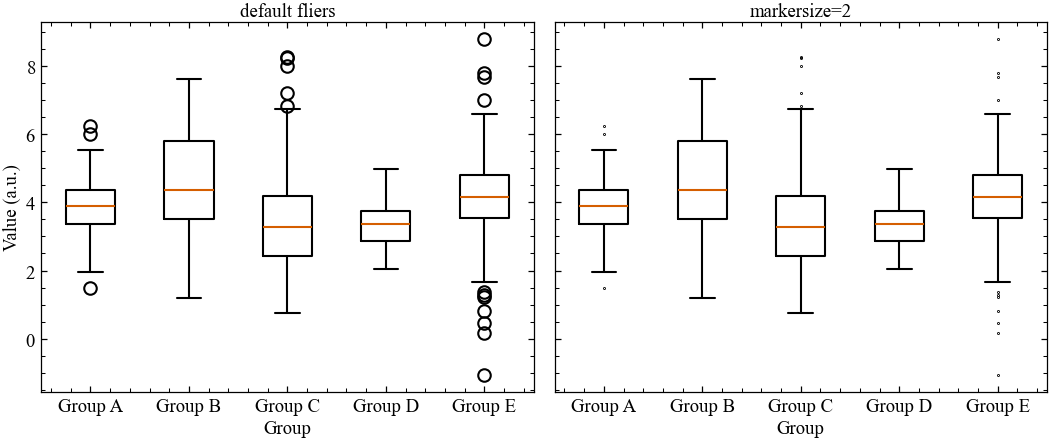

In [8]:
preview("aps")

fig, axs = jf.subplots("aps", 1, 2, width="double", ratio=0.42, sharey=True)

axs[0].boxplot(list(groups.values()))
axs[0].set_title("default fliers")

axs[1].boxplot(list(groups.values()),
               flierprops={"marker": ".", "markersize": 2, "markeredgewidth": 0.4})
axs[1].set_title("markersize=2")

for ax in axs:
    ax.set_xticks(range(1, len(groups) + 1), list(groups))
    ax.set_xlabel("Group")
axs[0].set_ylabel("Value (a.u.)")

print(f"markersize 2 pt is {2 * 25.4 / 72:.2f} mm across")
for violation in jf.check(fig, warn=False):
    print(" ", violation)

So 2 pt is below the APS minimum and the check says so. Settle it by picking a size that clears the
floor — 3 pt is 1.06 mm — rather than by ignoring the warning.

violations: []


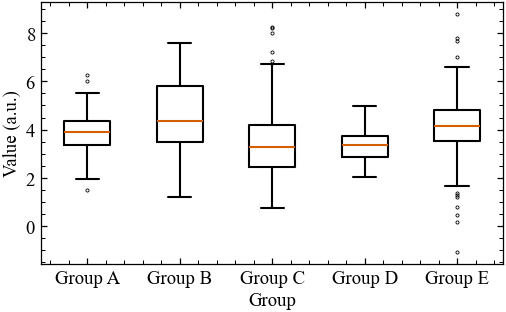

In [9]:
preview("aps")

fig, ax = jf.subplots("aps", width="single")
ax.boxplot(list(groups.values()),
           flierprops={"marker": ".", "markersize": 3, "markeredgewidth": 0.4})
ax.set_xticks(range(1, len(groups) + 1), list(groups))
ax.set_xlabel("Group")
ax.set_ylabel("Value (a.u.)")
print("violations:", jf.check(fig, warn=False))

## Show the data behind the summary

A box plot of eight points and a box plot of eight thousand look identical. That is the format's one
serious weakness, and overlaying the points fixes it: the box keeps the summary, the points show the
sample size, the gaps, and any clustering the five numbers cannot express.

Spread the points horizontally by a small random offset — *jitter* — or they pile onto one vertical
line. Draw them behind the box with `zorder` so the median stays legible.

violations: []


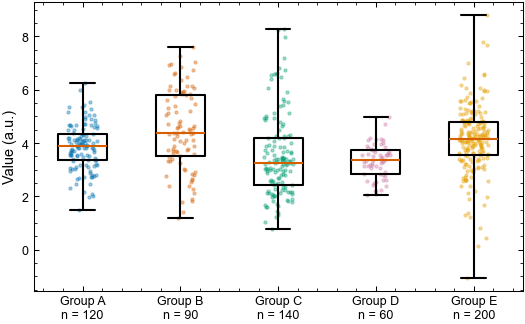

In [10]:
preview("nature")

fig, ax = jf.subplots("nature", width="single")
ax.boxplot(list(groups.values()), whis=(0, 100), widths=0.5, zorder=3)

for position, sample in enumerate(groups.values(), start=1):
    jitter = rng.uniform(-0.15, 0.15, sample.size)
    ax.plot(position + jitter, sample, linestyle="none", marker="o", markersize=1.5,
            alpha=0.35, zorder=2)

ax.set_xticks(range(1, len(groups) + 1), [f"{name}\nn = {s.size}" for name, s in groups.items()])
ax.set_ylabel("Value (a.u.)")
print("violations:", jf.check(fig, warn=False))

Two caveats on the overlay. It stops working somewhere in the low hundreds of points per group —
past that the cloud is a solid block and a violin plot or a histogram says more. And 1.5 pt markers
are 0.53 mm, under the APS minimum: Nature and Elsevier document no symbol floor, but the same figure
retargeted to APS would need larger points, fewer of them, or none.

## Notches, and when to believe them

`notch=True` narrows the box around the median by roughly ± 1.57 × IQR / √n — an approximate 95 %
confidence interval on the median. The rule of thumb: **if two notches do not overlap, the medians
probably differ.**

The approximation assumes a reasonably large, reasonably well-behaved sample. When `n` is small or
the distribution is far from normal the notch can extend past Q1 or Q3, and matplotlib draws the box
folded back on itself — which looks like a rendering bug and is really the figure telling you the
interval is wider than the middle half of the data.

group       n  notch half-width    as % of IQR
Group A   120             0.144            29 %
Group B    90             0.381            33 %
Group C   140             0.230            27 %
Group D    60             0.178            41 %
Group E   200             0.140            22 %


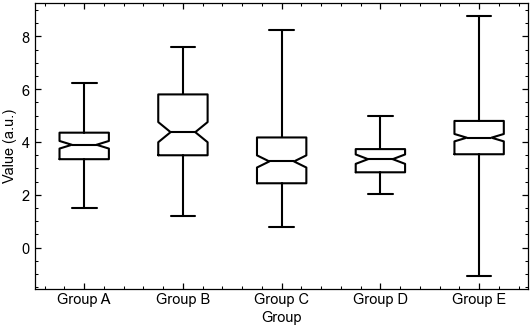

In [11]:
preview("elsevier")

fig, ax = jf.subplots("elsevier", width="single")
ax.boxplot(list(groups.values()), notch=True, whis=(0, 100),
           medianprops={"color": jf.COLORS["black"]})
ax.set_xticks(range(1, len(groups) + 1), list(groups))
ax.set_xlabel("Group")
ax.set_ylabel("Value (a.u.)")

print(f"{'group':8s} {'n':>4s} {'notch half-width':>17s}   {'as % of IQR':>12s}")
for name, sample in groups.items():
    q1, q3 = np.percentile(sample, [25, 75])
    half = 1.57 * (q3 - q1) / np.sqrt(sample.size)
    print(f"{name:8s} {sample.size:4d} {half:17.3f}   {200 * half / (q3 - q1):11.0f} %")

## Horizontal boxes

Long group names rotated to 45° are the usual reason a categorical figure looks cramped at 89 mm.
Turning the plot on its side puts the names on the y axis, where they read horizontally and have the
whole figure width to sit in.

The keyword for this was renamed: `vert=False` up to matplotlib 3.9, `orientation="horizontal"` from
3.10. Both work in 3.10 and 3.11, but neither works on both sides of that line, so pick by version.

matplotlib 3.10.8 -> {'orientation': 'horizontal'}
violations: []


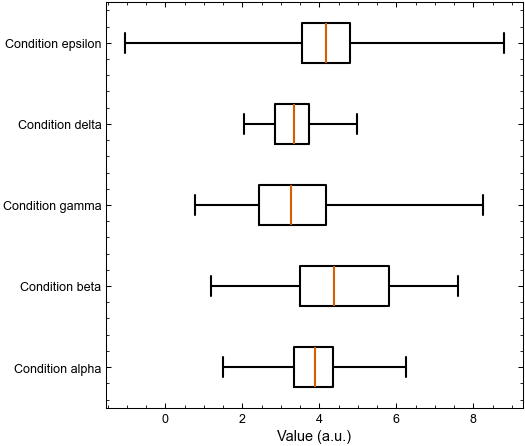

In [12]:
import matplotlib

# matplotlib 3.10 renamed vert=False to orientation="horizontal" and pending-deprecated the old name.
HORIZONTAL = ({"orientation": "horizontal"} if matplotlib.__version_info__ >= (3, 10)
              else {"vert": False})
print("matplotlib", matplotlib.__version__, "->", HORIZONTAL)

preview("nature")

long_names = ["Condition alpha", "Condition beta", "Condition gamma",
              "Condition delta", "Condition epsilon"]

fig, ax = jf.subplots("nature", width="single", ratio=0.85)
ax.boxplot(list(groups.values()), whis=(0, 100), **HORIZONTAL)
ax.set_yticks(range(1, len(groups) + 1), long_names)
ax.set_xlabel("Value (a.u.)")
print("violations:", jf.check(fig, warn=False))

Ordering is worth one more thought once the plot is horizontal. Groups arrive in whatever order the
data happened to be in; sorting by median turns the panel into a ranking and makes the comparison the
figure exists for readable at a glance.

ordered by median: Group C < Group D < Group A < Group E < Group B


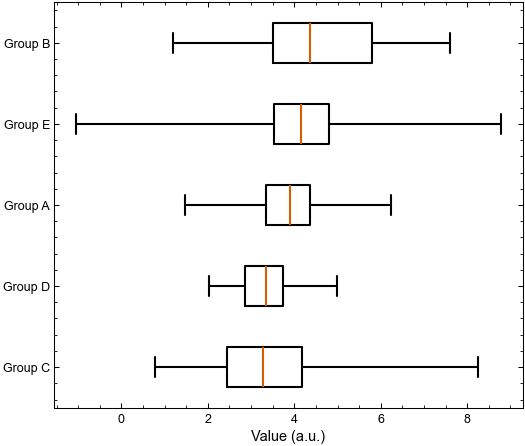

In [13]:
preview("nature")

order = sorted(groups, key=lambda name: np.median(groups[name]))

fig, ax = jf.subplots("nature", width="single", ratio=0.85)
ax.boxplot([groups[name] for name in order], whis=(0, 100), **HORIZONTAL)
ax.set_yticks(range(1, len(order) + 1), order)
ax.set_xlabel("Value (a.u.)")
print("ordered by median:", " < ".join(order))

## Save it

`jf.save()` writes PDF, SVG and PNG, runs `jf.check()` on the way past, and reports what it wrote.
A box plot is a handful of line segments, so the vector files are tiny — this is the case where
rasterizing would cost quality for no saving at all.

In [14]:
import tempfile
from pathlib import Path

outdir = Path(tempfile.mkdtemp())
written = jf.save(fig, outdir / "boxplot")

print()
for path in written:
    print(f"  {path.name:18s} {path.stat().st_size / 1024:7.1f} kB")

Nature Portfolio: 89.0 x 75.6 mm -> boxplot.pdf, boxplot.svg, boxplot.png



  boxplot.pdf           17.1 kB
  boxplot.svg           28.4 kB
  boxplot.png           24.8 kB


## When not to use a box plot

- **Two modes.** A bimodal distribution and a flat one can give identical five-number summaries. The
  box plot cannot show the difference; a histogram or a violin plot can.
- **Very small samples.** Below about eight points per group, quartiles are noise. Plot the points.
- **One group.** Five numbers do not need a figure — a histogram shows more, or write them in the text.